# Exercise 1 — Notebook 2: Customer Behaviour and Characteristics

## Purpose of this notebook

This notebook answers Task 1.1 of the exercise: describe the customer 
behaviour and characteristics of Advanzia's credit card portfolio.

We load the cleaned dataset from notebook 1 and build the analysis in three 
parts:

1. **Static portfolio composition** — who these customers are (credit limits, 
   tenure) before looking at any behaviour
2. **Usage behaviour** — how they actually use the card (utilisation bands, 
   Transactor/Revolver/Mixed segmentation)
3. **Time dimension** — how portfolio-level behaviour evolves across the 
   12-month observation window

Each section leads with a short explanation of what we're looking at and why 
it matters for credit risk, followed by the calculation, followed by a short 
interpretation of the result.

## Step 1: Load the cleaned dataset

We load the parquet file saved at the end of notebook 1, which already 
contains all derived columns (utilisation ratio, capped repayment ratio, 
capped payment compliance ratio, default flag) — so this notebook can go 
straight into analysis without repeating any data preparation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
df = pd.read_excel('data/cleaned_portfolio_data.xlsx')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Unique customers: {df['CustomerID'].nunique()}")
df.dtypes

Shape: 12000 rows, 18 columns
Unique customers: 1000


CustomerID                                 object
ForDate                            datetime64[ns]
Age_FU                                      int64
OpeningBalance                            float64
ClosingBalance                            float64
CreditLimit                                 int64
MinPaymentAmount                          float64
Payments                                  float64
MonthsPastDue                              object
MonthsPastDue_num                           int64
MonthsPastDue_label                        object
is_default                                   bool
utilisation_ratio                         float64
repayment_ratio                           float64
repayment_ratio_capped                    float64
has_negative_payment                         bool
payment_compliance_ratio                  float64
payment_compliance_ratio_capped           float64
dtype: object

In [2]:
df.head(13)

,CustomerID,ForDate,Age_FU,OpeningBalance,ClosingBalance,CreditLimit,MinPaymentAmount,Payments,MonthsPastDue,MonthsPastDue_num,MonthsPastDue_label,is_default,utilisation_ratio,repayment_ratio,repayment_ratio_capped,has_negative_payment,payment_compliance_ratio,payment_compliance_ratio_capped
0,ID1,2022-10-01,9,158.01,233.13,6000,30.00,30.00,0,0,0,False,0.038855,0.189861,0.189861,False,1.000000,1.000000
1,ID1,2022-11-01,10,233.13,453.95,6000,30.00,793.50,0,0,0,False,0.075658,3.403680,3.403680,False,26.450000,26.450000
2,ID1,2022-12-01,11,453.95,57.00,6000,30.00,521.09,0,0,0,False,0.009500,1.147902,1.147902,False,17.369667,17.369667
3,ID1,2023-01-01,12,57.00,33.64,6000,30.00,380.00,0,0,0,False,0.005607,6.666667,6.666667,False,12.666667,12.666667
4,ID1,2023-02-01,13,33.64,15.07,6000,30.00,30.00,0,0,0,False,0.002512,0.891795,0.891795,False,1.000000,1.000000
5,ID1,2023-03-01,14,15.07,57.58,6000,15.07,123.06,0,0,0,False,0.009597,8.165893,8.165893,False,8.165893,8.165893
6,ID1,2023-04-01,15,57.58,50.13,6000,30.00,93.50,0,0,0,False,0.008355,1.623828,1.623828,False,3.116667,3.116667
7,ID1,2023-05-01,16,50.13,59.36,6000,30.00,593.43,0,0,0,False,0.009893,11.837822,11.837822,False,19.781000,19.781000
8,ID1,2023-06-01,17,59.36,839.31,6000,30.00,915.00,0,0,0,False,0.139885,15.414420,15.414420,False,30.500000,30.500000
9,ID1,2023-07-01,18,839.31,1198.48,6000,30.00,320.00,0,0,0,False,0.199747,0.381266,0.381266,False,10.666667,10.666667


---

## Part A: Static portfolio composition

Before looking at behaviour, we look at who these customers are structurally — 
their assigned credit limit and how long they've held the card. This gives 
us the baseline context everything else builds on.

**Important note on approach:** the raw data has 12 rows per customer (one 
per month). For "who is this customer" questions, we need **one row per 
customer**, not twelve — so we collapse the monthly panel down to a 
customer-level summary first. We use each customer's **first observed month** 
for `CreditLimit` and `Age_FU`, since limits can change mid-year (we saw this 
with ID834 going from 3000 to 6000) and we want their starting position here, 
not a mix of different points in time.

In [3]:
#here we build a customer-level snapshot using each customer's first observed month
customer_snapshot = (df.sort_values(['CustomerID', 'ForDate'])
      .groupby('CustomerID')
      .first()[['Age_FU', 'CreditLimit']]
      .reset_index())

#also capture the LAST month's credit limit, to check if/how many limits changed
customer_last=(df.sort_values(['CustomerID', 'ForDate'])
      .groupby('CustomerID')
      .last()[['CreditLimit']]
      .reset_index()
      .rename(columns={'CreditLimit': 'CreditLimit_end'}))

customer_snapshot=customer_snapshot.merge(customer_last,on='CustomerID')
customer_snapshot['limit_changed']=customer_snapshot['CreditLimit']!=customer_snapshot['CreditLimit_end']
print(f"Total customers: {len(customer_snapshot)}")
print(f"Customers whose credit limit changed during the year: {customer_snapshot['limit_changed'].sum()}")
print()
customer_snapshot.head()

Total customers: 1000
Customers whose credit limit changed during the year: 481



,CustomerID,Age_FU,CreditLimit,CreditLimit_end,limit_changed
0,ID1,9,6000,6000,False
1,ID10,3,200,200,False
2,ID100,1,1500,6000,True
3,ID1000,1,1800,6000,True
4,ID101,5,800,1800,True


as you can see 481 of 1,000 customers had their credit limit changed during the observation window, confirming Advanzia actively manages limits on this portfolio rather than leaving them static

### Credit limit distribution

We look at the distribution of starting credit limits across the 1,000 
customers. This shows the risk appetite range Advanzia is operating in for 
this portfolio — from very small limits to several thousand euros.

Credit limit summary statistics (starting limit):
count    1000.000000
mean     2356.450000
std      1593.814965
min       100.000000
25%      1000.000000
50%      2000.000000
75%      3000.000000
max      6000.000000
Name: CreditLimit, dtype: float64



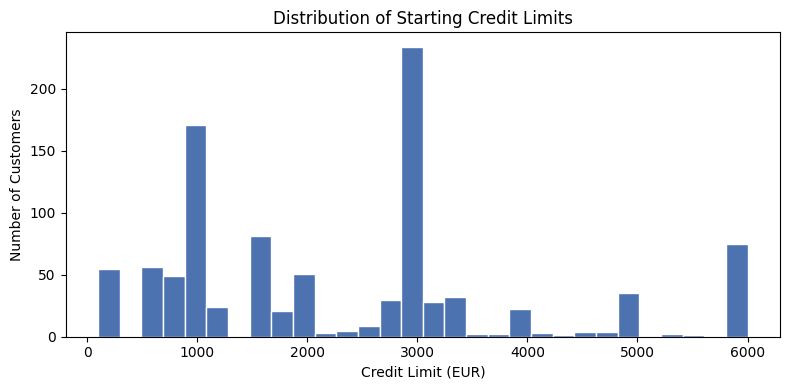

In [4]:
print("Credit limit summary statistics (starting limit):")
print(customer_snapshot['CreditLimit'].describe())
print()
plt.figure(figsize=(8,4))
plt.hist(customer_snapshot['CreditLimit'],bins=30,color='#4C72B0',edgecolor='white')
plt.xlabel('Credit Limit (EUR)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Starting Credit Limits')
plt.tight_layout()
plt.savefig('figures/credit_limit_distribution.png', dpi=150)
plt.show()

**Interpretation:** 

Credit limits range from €100 to €6,000, with a median 
of €2,000 and mean of €2,356. The distribution is **not smooth (not normanl)** — it shows 
distinct spikes at specific values, most notably around €1,000, €3,000 (the 
single largest cluster, with over 200 customers), and €6,000, with relatively 
few customers in between. This pattern suggests the bank assigns limits 
from a **set of standard tiers**. We'll keep this tiered structure in mind 
when looking at utilisation later, since a customer's utilisation percentage 
is naturally affected by which tier they happen to fall into.

### Customer tenure (Age_FU) distribution

`Age_FU` tells us how many months a customer has held the card at the start 
of our observation window. This matters because customer behaviour is known 
to change with tenure a phenomenon called **"seasoning"** in credit risk: 
newly acquired customers often behave differently (sometimes riskier, 
sometimes more cautious) than long-standing, seasoned customers. Knowing the 
tenure mix tells us whether this portfolio is mostly new customers, mostly 
seasoned ones, or a mix.

Age_FU (tenure at start of window) summary statistics:
count    1000.000000
mean        5.537000
std         3.387936
min         1.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        12.000000
Name: Age_FU, dtype: float64



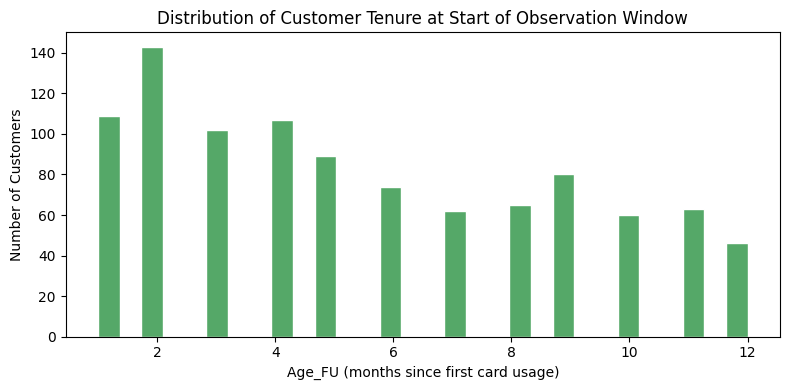

In [5]:
print("Age_FU (tenure at start of window) summary statistics:")
print(customer_snapshot['Age_FU'].describe())
print()

plt.figure(figsize=(8,4))
plt.hist(customer_snapshot['Age_FU'],bins=30,color='#55A868',edgecolor='white')
plt.xlabel('Age_FU (months since first card usage)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure at Start of Observation Window')
plt.tight_layout()
plt.savefig('figures/age_fu_distribution.png', dpi=150)
plt.show()

**Interpretation:** `Age_FU` measures tenure since first card usage — how 
many months ago a customer first used their card. At the start of our observation window, tenure ranges from 1 
to 12 months, with a median of 5 months and mean of 5.5 months. The 
distribution is right-skewed toward newer customers: the largest group 
(over 140 customers) had only started using their bcard 1-2 months and the count steadily declines toward longer-tenure customers, 
with only around 45 customers having a full 12 months of tenure already. 

This is a typical pattern for a growing card portfolio: a steady stream of 
newly acquired customers, with naturally fewer customers reaching longer 
tenures simply because they joined more recently as per our 12 months data.

This matters for the **seasoning effect** we'll examine this in the risk indictors section : this 
portfolio skews toward relatively new customers, so if newer-tenure customers 
behave differently from seasoned ones in terms of default risk, that 
skew will meaningfully shape the overall portfolio-level default rate we 
observe.

---

## Part B: Usage behaviour

Now we move from "who they are" to "how they actually use the card." This 
section has two pieces: utilisation bands (how much of their limit they use) 
and a Transactor/Revolver/Mixed segmentation (how they repay what they owe).

For this section we need **customer-level averages across all 12 months**, 
not just a single snapshot month, since we want to characterise each 
customer's typical behaviour over the full observation window.

In [6]:
#customer-level average utilisation and repayment behaviour across all 12 months
customer_behaviour = df.groupby('CustomerID').agg(
    avg_utilisation=('utilisation_ratio', 'mean'),
    avg_repayment_ratio=('repayment_ratio_capped', 'mean'),
    avg_balance=('ClosingBalance', 'mean'),
    ever_default=('is_default', 'max')   # True if customer ever reached 4+ at any point
).reset_index()

print(f"Customer-level behaviour summary built for {len(customer_behaviour)} customers")
customer_behaviour.head()

Customer-level behaviour summary built for 1000 customers


,CustomerID,avg_utilisation,avg_repayment_ratio,avg_balance,ever_default
0,ID1,0.046807,4.519675,280.841667,False
1,ID10,0.920000,2.249279,184.000000,False
2,ID100,0.045382,0.925889,143.629167,False
3,ID1000,0.154408,1.727473,532.259167,False
4,ID101,0.944135,0.071792,1483.084167,False


### Utilisation bands

Using the same four-band definition established in notebook 1:
- 0-10%: lowest risk exposure
- 11-30%: safe zone (the "30% Rule" — most institutions view staying under 
  30% as the minimum bar for responsible credit use)
- 31-50%: moderate risk
- 50%+: high risk — heavy reliance on available credit, an established 
  early-warning signal for future default

We classify each customer into one band based on their average utilisation 
across the year, then look at how many customers fall into each band and 
whether default incidence differs meaningfully by band — this is a first 
look at whether utilisation behaviour actually relates to default outcomes 
in this portfolio.

In [7]:
def utilisation_band(u):
    if u<=0.10:
        return '0-10% (Lowest Risk)'
    elif 0.10<u<=0.30:
        return '11-30% (Safe Zone)'
    elif 0.30<u<=0.50:
        return '31-50% (Moderate Risk)'
    else:
        return '50%+ (High Risk)'

customer_behaviour['utilisation_band']=customer_behaviour['avg_utilisation'].apply(utilisation_band)
band_order=['0-10% (Lowest Risk)','11-30% (Safe Zone)','31-50% (Moderate Risk)','50%+ (High Risk)']
band_summary=customer_behaviour.groupby('utilisation_band').agg(num_customers=('CustomerID', 'count'),
    avg_balance=('avg_balance','mean'),
    default_rate=('ever_default','mean')).reindex(band_order)

band_summary['default_rate']=(band_summary['default_rate']*100).round(2)
band_summary['avg_balance']=band_summary['avg_balance'].round(2)
print("Customer count, average balance, and default rate by utilisation band:")
band_summary

Customer count, average balance, and default rate by utilisation band:


,num_customers,avg_balance,default_rate
utilisation_band,,,
0-10% (Lowest Risk),347,108.81,1.44
11-30% (Safe Zone),155,611.76,13.55
31-50% (Moderate Risk),97,1230.32,23.71
50%+ (High Risk),401,2101.80,13.97


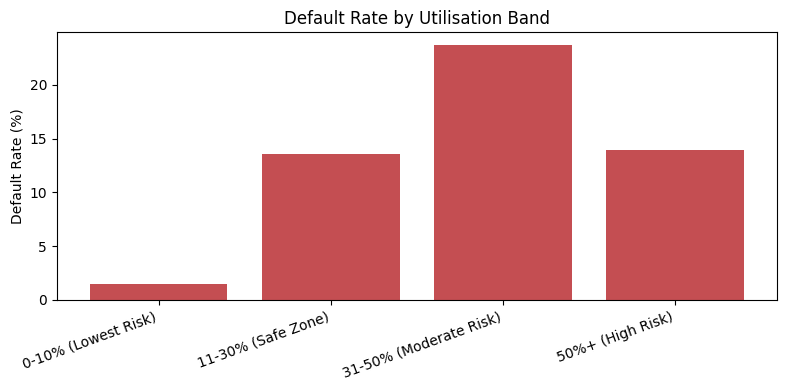

In [8]:
plt.figure(figsize=(8, 4))
plt.bar(band_summary.index, band_summary['default_rate'], color='#C44E52')
plt.ylabel('Default Rate (%)')
plt.title('Default Rate by Utilisation Band')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/default_rate_by_utilisation_band.png', dpi=150)
plt.show()

**Interpretation**

The default rate does not follow a simple pattern. It rises sharply across the first three groups from 1.4% to 23.7% but drops in the highest usage group, even though that group has the largest balances.This happens because of how averages work. Once a customer defaults, the bank blocks their account. This freezes their usage percentage and stops it from climbing higher. Therefore, the highest group is a confusing mix of two different groups: safe customers with high limits and accounts that froze early because of a default.The most important finding is the 31% to 50% usage group. This is actually the riskiest group. It shows that watching someone's usage rise over time is a much stronger warning sign than someone just staying at a high, steady level. I will look into this using trend data

### Transactor / Revolver / Mixed segmentation

This is genuine credit card industry language:

- **Transactor:** consistently pays back most/all of their balance each 
  month (average repayment ratio >= 0.9) — generates fee income for the 
  bank with minimal credit risk
- **Revolver:** consistently pays close to the minimum, carrying a balance 
  month to month (average repayment ratio < 0.3) — generates interest income 
  but carries materially higher credit risk
- **Mixed:** behaviour in between — sometimes pays in full, sometimes 
  revolves

These cutoffs (0.9 and 0.3) are a reasonable, judgment-based split, we have not 
derived from a formula we have chosen this to capture clearly distinct behavioural 
extremes while leaving a meaningful "mixed" middle group

In [9]:
def behaviour_segment(r):
    if pd.isna(r):
        return 'Insufficient Data'
    elif r>=0.9:
        return 'Transactor'
    elif r<0.3:
        return 'Revolver'
    else:
        return 'Mixed'

customer_behaviour['segment']=customer_behaviour['avg_repayment_ratio'].apply(behaviour_segment)
segment_summary=customer_behaviour.groupby('segment').agg(num_customers=('CustomerID','count'),
    avg_balance=('avg_balance','mean'),
    avg_utilisation=('avg_utilisation','mean'),
    default_rate=('ever_default','mean'))

segment_summary['default_rate']=(segment_summary['default_rate']*100).round(2)
segment_summary['avg_balance']=segment_summary['avg_balance'].round(2)
segment_summary['avg_utilisation']=(segment_summary['avg_utilisation']*100).round(1)
print("Behavioural segment summary:")
segment_summary.sort_values('default_rate', ascending=True)

Behavioural segment summary:


,num_customers,avg_balance,avg_utilisation,default_rate
segment,,,,
Transactor,323,386.90,13.0,0.31
Mixed,174,803.51,26.5,1.72
Revolver,503,1650.02,64.8,20.08


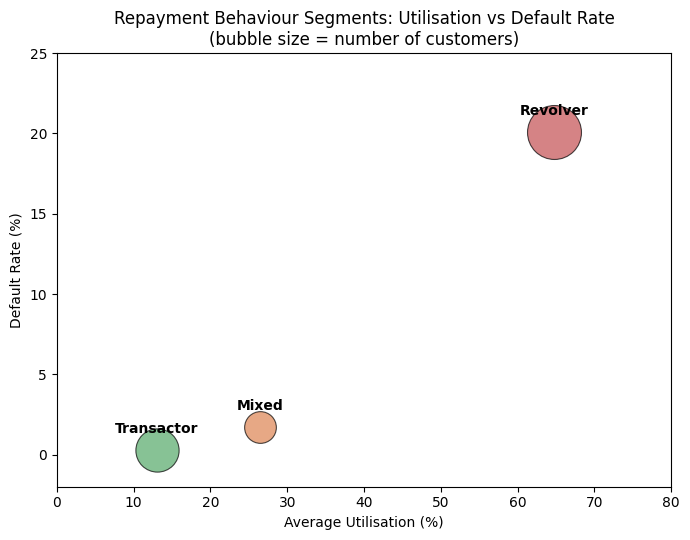

In [10]:
fig,ax=plt.subplots(figsize=(7,5.5))
colors={'Transactor': '#55A868', 'Mixed': '#DD8452', 'Revolver': '#C44E52'}

for segment in segment_summary.index:
    row=segment_summary.loc[segment]
    ax.scatter(row['avg_utilisation'], 
        row['default_rate'],
        s=row['num_customers'] * 3,   # bubble size scaled by customer count
        color=colors[segment],
        alpha=0.7,
        edgecolor='black',
        linewidth=0.8,
        label=f"{segment} (n={int(row['num_customers'])})")
    #Label each bubble directly with the segment name
    ax.annotate(
        segment,
        (row['avg_utilisation'],row['default_rate']),
        textcoords="offset points",xytext=(0, 12),
        ha='center', fontsize=10,fontweight='bold')

ax.set_xlabel('Average Utilisation (%)')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Repayment Behaviour Segments: Utilisation vs Default Rate\n(bubble size = number of customers)')
ax.set_xlim(0, 80)
ax.set_ylim(-2, 25)
plt.tight_layout()
plt.savefig('figures/segment_utilisation_vs_default.png', dpi=150)
plt.show()

This is the clearest finding in my analysis. Balance, usage, and default rates all rise dramatically together as customers move from Transactors, to Mixed users, to Revolvers.In fact, Revolvers default at a rate of about 20%, which is roughly 65 times higher than the Transactor rate of 0.3%. This explains why looking at usage percentages alone was confusing. High usage only tells part of the story. The real risk happens when high usage combines with making only minimum payments. Finally, Revolvers are not a small, isolated group. They make up over half of all customers and hold the highest balances, meaning a massive amount of risk is concentrated in this one group

**How this helps, and what action it supports:** This segmentation gives the 
Bank a ready made, low cost early warning lens that requires no new data.
repayment ratio is already calculated from existing monthly statements. 
Because Revolvers carry a default rate roughly 65 times higher than 
Transactors, this segment could be used immediately to prioritise existing 
monitoring resources: Revolver accounts could be reviewed more frequently, 
flagged for earlier collections contact if they show any sign of 
deterioration, or considered for more conservative credit limit increase 
decisions going forward. Because over half the portfolio falls into this 
segment, even a modest improvement in how Revolver risk is managed would 
have a meaningful effect on overall portfolio loss.

---

## Part C: Time dimension

Finally, we look at whether portfolio-level behaviour changes across the 
12 months data. This is a first look at trend and seasonality — 
we'll go deeper on this in risk indicators section, but it belongs here 
too since it's part of describing overall customer behaviour.

In [11]:
monthly_behaviour=df.groupby('ForDate').agg(avg_utilisation=('utilisation_ratio','mean'),
    avg_closing_balance=('ClosingBalance','mean'),
    num_customers=('CustomerID', 'nunique')).reset_index()
print(monthly_behaviour)

      ForDate  avg_utilisation  avg_closing_balance  num_customers
0  2022-10-01         0.430878            813.49421           1000
1  2022-11-01         0.432846            887.52904           1000
2  2022-12-01         0.434969            972.29474           1000
3  2023-01-01         0.423232            999.93461           1000
4  2023-02-01         0.411732           1045.17530           1000
5  2023-03-01         0.407893           1071.68579           1000
6  2023-04-01         0.399095           1110.47426           1000
7  2023-05-01         0.400712           1142.15249           1000
8  2023-06-01         0.406111           1221.53588           1000
9  2023-07-01         0.402148           1237.91215           1000
10 2023-08-01         0.415010           1309.80595           1000
11 2023-09-01         0.403918           1324.91144           1000


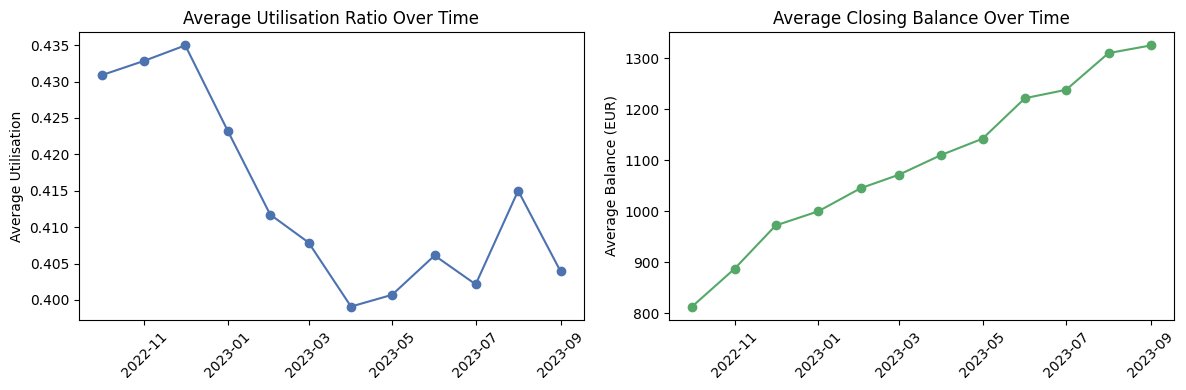

In [12]:
fig, axes=plt.subplots(1,2,figsize=(12, 4))
axes[0].plot(monthly_behaviour['ForDate'],monthly_behaviour['avg_utilisation'],marker='o', color='#4C72B0')
axes[0].set_title('Average Utilisation Ratio Over Time')
axes[0].set_ylabel('Average Utilisation')
axes[0].tick_params(axis='x',rotation=45)
axes[1].plot(monthly_behaviour['ForDate'], monthly_behaviour['avg_closing_balance'],marker='o',color='#55A868')
axes[1].set_title('Average Closing Balance Over Time')
axes[1].set_ylabel('Average Balance (EUR)')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.savefig('figures/monthly_behaviour_trend.png', dpi=150)
plt.show()

**Interpretation**

These two charts look like they disagree at first balance is rising steadily all year, but utilisation actually falls for the first half of the year. The explanation connects back to something I found earlier: a meaningful number of customers had their credit limit increased during the year. When limits grow alongside balances, the ratio can stay flat or even fall even though the actual euro exposure keeps climbing. So this is a good reminder that utilisation and total balance tell you different things — you need both, not just one, to see the real exposure picture.

## Summary of Task 1.1 findings

**Portfolio composition:** The 1,000 customers hold credit limits ranging 
from €100 to €6,000 (median €2,000), assigned from a small set of standard 
tiers rather than a continuous range, with clear clusters around €1,000, 
€3,000, and €6,000. Tenure (`Age_FU`) at the start of the window skews toward 
newer customers (median 5 months, peaking at 1-2 months), with a long thinning 
tail of more seasoned customers up to 12 months. Just under half the 
portfolio (481 of 1,000 customers) had their credit limit changed during the 
year, confirming active, ongoing limit management rather than static 
limit-setting.

**Usage behaviour:** Utilisation bands alone show a non-monotonic relationship 
with default rate rising sharply from 1.4% to 23.7% across the first three 
bands, then falling to 13.97% in the highest band best explained by accounts 
freezing at a static high utilisation after an early default, which blends 
two different customer stories into one average. Repayment behaviour proved 
to be the much stronger and cleaner risk signal: classifying customers as 
**Transactors** (323 customers, 0.31% default rate), **Mixed** (174 customers, 
1.72%), or **Revolvers** (503 customers, 20.08%) shows a fully monotonic 
relationship across balance, utilisation, and default risk simultaneously. 
Revolvers over half the portfolio carry both the highest balances and a 
default rate roughly 65 times that of Transactors, representing a material 
concentration of credit risk within a single behavioural segment.

**Time dimension:** Average closing balance rose steadily and consistently 
across the 12-month window (€813 to €1,325), while average utilisation moved 
choppily and even declined for the first half of the year. This apparent 
contradiction is resolved by the limit-change finding above: as credit 
limits were raised across the portfolio, the utilisation ratio's denominator 
grew alongside the numerator, allowing the ratio to stay flat or fall even 
as absolute exposure kept climbing — a reminder that utilisation and total 
balance must be read together, not as substitutes, when assessing portfolio 
exposure.

**Overall:** Repayment behaviour (Transactor/Revolver/Mixed) is the clearest 
and most actionable behavioural risk signal identified in this analysis, 
materially stronger than utilisation viewed in isolation. These findings — 
particularly the Revolver segment's concentration of risk and the seasoning/
tenure mix — are carried forward into notebook 3, where we build formal risk 
indicators (default rate, roll rates) and examine the pre-default utilisation 
trajectory directly to further test the patterns found here.